# TP 2 — métriques de régression

Mesurer un modèle de régression, puis regarder *comment* il se trompe.

## 1.0 Prédire la progression du diabète

`load_diabetes` donne 442 patients, 10 caractéristiques mesurées au départ (âge, sexe, IMC, tension, six analyses sanguines) et une cible $y$ : la progression de la maladie un an plus tard, de 25 à 346.

`model` est une régression linéaire entraînée sur 353 de ces patients ; les 89 autres forment le test, et ce sont ses prédictions $\hat y$ sur eux que nous mesurons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

X, y = load_diabetes(return_X_y=True)
noise = np.random.default_rng(0).normal(size=(len(X), 342))   # pure-noise columns, added in 1.3
X_train, X_test, y_train, y_test, noise_train, noise_test = train_test_split(
    X, y, noise, test_size=0.2, random_state=0)
model = LinearRegression().fit(X_train, y_train)
y_hat = model.predict(X_test)

## 1.1 Quatre résumés des mêmes résidus

Le résidu du patient $i$ est son erreur, $e^{(i)} = y^{(i)} - \hat y^{(i)}$. Quatre métriques résument les $m$ résidus en un seul chiffre :

$$\text{MSE} = \frac{1}{m}\sum_{i=1}^{m}\big(\hat y^{(i)} - y^{(i)}\big)^2, \qquad \text{RMSE} = \sqrt{\text{MSE}}, \qquad \text{MAE} = \frac{1}{m}\sum_{i=1}^{m}\big|\hat y^{(i)} - y^{(i)}\big|,$$

$$R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}, \qquad \text{SS}_{\text{res}} = \sum_{i=1}^{m}\big(y^{(i)} - \hat y^{(i)}\big)^2, \qquad \text{SS}_{\text{tot}} = \sum_{i=1}^{m}\big(y^{(i)} - \bar y\big)^2.$$

Écrivez-les avec numpy, sans boucle, à partir des seuls arguments `y` et `y_hat`.

**Q1.** Les résidus se comptent en points de progression, sur une échelle qui va de 25 à 346. Sans rien exécuter : dans quelle unité s'exprime chacune des quatre métriques, et laquelle du RMSE ou de la MAE sera la plus grande ? Et la ligne de base « prédire la moyenne du train » : quel R² attendez-vous d'elle ?

**Réponse attendue :** MSE en points², RMSE et MAE en points, R² sans unité (un rapport de deux sommes de carrés), ce qui permet de comparer des problèmes d'échelles différentes. Le RMSE sera le plus grand : la racine d'une moyenne de carrés donne du poids aux grosses erreurs, et RMSE ≥ MAE toujours, avec égalité seulement si toutes les erreurs ont la même taille.

Pour la ligne de base on attend un R² très légèrement **négatif**, pas exactement 0 — et c'est là le piège : le R² compare à la meilleure constante *sur les données évaluées*, c'est-à-dire la moyenne du **test**, alors que cette ligne de base prédit celle du **train**.

In [2]:
def mse(y, y_hat):
    return np.mean((y_hat - y) ** 2)


def rmse(y, y_hat):
    return np.sqrt(mse(y, y_hat))


def mae(y, y_hat):
    return np.mean(np.abs(y_hat - y))


def r2(y, y_hat):
    """1 - SS_res / SS_tot, where SS_tot uses the mean of the true values y."""
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot


assert np.isclose(mse(y_test, y_hat), mean_squared_error(y_test, y_hat))
assert np.isclose(rmse(y_test, y_hat), np.sqrt(mean_squared_error(y_test, y_hat)))
assert np.isclose(mae(y_test, y_hat), mean_absolute_error(y_test, y_hat))
assert np.isclose(r2(y_test, y_hat), r2_score(y_test, y_hat))
# same functions on the training set: they must read their arguments, not y_test
y_hat_train = model.predict(X_train)
assert np.isclose(mse(y_train, y_hat_train), mean_squared_error(y_train, y_hat_train))
assert np.isclose(rmse(y_train, y_hat_train), np.sqrt(mean_squared_error(y_train, y_hat_train)))
assert np.isclose(mae(y_train, y_hat_train), mean_absolute_error(y_train, y_hat_train))
assert np.isclose(r2(y_train, y_hat_train), r2_score(y_train, y_hat_train))

y_baseline = np.full(len(y_test), y_train.mean())   # a "model" that ignores x and always predicts the train mean

print(f"moyenne de y : {y_train.mean():.1f} sur le train, {y_test.mean():.1f} sur le test")
pd.DataFrame([[f(y_test, p) for f in (mse, rmse, mae, r2)] for p in (y_hat, y_baseline)],
             index=["modèle", "moyenne du train"],
             columns=["MSE", "RMSE", "MAE", "R²"]).round({"MSE": 1, "RMSE": 2, "MAE": 2, "R²": 4})

moyenne de y : 151.6 sur le train, 154.2 sur le test


,MSE,RMSE,MAE,R²
modèle,3424.3,58.52,46.17,0.3322
moyenne du train,5134.8,71.66,59.23,-0.0013


**Q2.** Traduisez le RMSE en une phrase pour un médecin. La ligne de base obtient-elle exactement $R^2 = 0$ ? Chiffrez l'écart, et dites ce qu'il faudrait changer à cette ligne de base pour qu'elle l'obtienne exactement. Et que dit le R² du modèle sur ce qu'il a appris ?

**Réponse attendue :** « Le modèle se trompe typiquement d'une soixantaine de points sur la progression à un an » : RMSE 58,52, MAE 46,17, sur une échelle de 25 à 346.

Non : la ligne de base obtient −0,0013. $\text{SS}_{\text{tot}}$ utilise la moyenne du **test** (154,2) alors qu'elle prédit celle du **train** (151,6) : son MSE vaut 5134,8 au lieu des 5127,9 qu'elle aurait atteints en connaissant la moyenne du test. Il faudrait donc lui faire prédire `y_test.mean()` pour qu'elle obtienne exactement 0 — mais cette moyenne n'est pas connue au moment de l'entraînement, et s'en servir serait déjà regarder le test.

Le R² du modèle, 0,332, dit qu'il retire un tiers de la variance de la cible : mieux que la moyenne, loin d'une prédiction fiable patient par patient — son RMSE ne descend qu'à 82 % de celui de la ligne de base (58,52 contre 71,66).

## 1.2 Un zéro de trop à la saisie

Le patient 0 du test a une progression de 321 ; à la saisie, quelqu'un a tapé 3210. Le modèle, lui, ne change pas : sa prédiction pour ce patient est la même qu'avant, mais son erreur sur lui grandit de 2 889 points.

**Q3.** Par combien attendez-vous que le RMSE et la MAE soient multipliés — par le même facteur ?

**Réponse attendue :** Non, pas du tout par le même. La MAE ne gagne que $2889/89 \approx 32$ points sur la quarantaine qu'elle vaut : un facteur de l'ordre de 1,7. Le RMSE travaille sur des carrés, et une erreur de près de 3 000 points, mise au carré, dépasse à elle seule la somme des 89 carrés d'avant : facteur de l'ordre de 5.

Le piège : annoncer le même facteur pour les deux (« l'erreur de ce patient explose, donc les deux métriques explosent pareil »). Le carré change l'échelle de l'accident, la valeur absolue non.

In [3]:
y_test_typo = y_test.copy()
y_test_typo[0] = 3210            # one extra zero at data entry; the true value is 321

metrics = (mse, rmse, mae, r2)
before = [f(y_test, y_hat) for f in metrics]
after = [f(y_test_typo, y_hat) for f in metrics]
assert np.allclose(after[1:3], [np.sqrt(mean_squared_error(y_test_typo, y_hat)),
                                mean_absolute_error(y_test_typo, y_hat)])

table = pd.DataFrame({"avant": before, "après": after}, index=["MSE", "RMSE", "MAE", "R²"])
table["facteur"] = table["après"] / table["avant"]
table.loc["R²", "facteur"] = np.nan          # a ratio of two R² would mean nothing

print(f"ce seul patient (ŷ = {y_hat[0]:.1f}) pèse "
      f"{100 * (y_test_typo[0] - y_hat[0]) ** 2 / np.sum((y_test_typo - y_hat) ** 2):.1f} %"
      " de la somme des carrés des erreurs")
table.round(2)

ce seul patient (ŷ = 238.5) pèse 96.7 % de la somme des carrés des erreurs


,avant,après,facteur
MSE,3424.26,102561.14,29.95
RMSE,58.52,320.25,5.47
MAE,46.17,78.63,1.70
R²,0.33,0.06,NaN


**Q4.** Le R² tombe de 0,33 à 0,06 alors que le modèle n'a pas bougé : pourquoi une métrique sans unité, censée se comparer d'un problème à l'autre, encaisse-t-elle autant — que deviennent $\text{SS}_{\text{res}}$ *et* $\text{SS}_{\text{tot}}$, et pourquoi le tableau refuse-t-il de lui donner un facteur ? Quelle métrique rapporter si les données peuvent contenir des erreurs de saisie, et que faut-il faire des données elles-mêmes ?

**Réponse attendue :** Le MSE **élève au carré** l'erreur de 2971,5 points : ce seul patient sur 89 pèse 96,7 % de la somme des carrés, le MSE est multiplié par 29,95 et le RMSE par 5,47 (58,52 → 320,25). La MAE ne l'ajoute que **linéairement** : $+(2971{,}5 - 82{,}5)/89 = 32{,}46$ points, soit 78,63 contre 46,17 — facteur 1,70.

Le R² n'est sans unité que parce qu'il divise deux sommes de carrés, et la faute de saisie gonfle les deux : $\text{SS}_{\text{res}}$ est multipliée par 29,95, mais $\text{SS}_{\text{tot}}$ par 21,19, puisque 3210 s'éloigne aussi énormément de $\bar y$. Les deux gonflent, mais pas au même rythme, et le R² tombe de 0,332 à 0,056. Un facteur entre deux R² ne voudrait rien dire — un R² peut être nul ou négatif, et 0,06/0,33 ne se lit pas comme « six fois moins bon » : d'où le `NaN` de la colonne.

Si les données peuvent contenir des erreurs de saisie, on rapporte la MAE ; mais surtout, on **corrige les données**. Le modèle n'a pas changé : seule la mesure de sa qualité a été faussée.

## 1.3 Les deux visages du R²

$R^2 = 0$, c'est « aussi bien que prédire $\bar y$ » ; $R^2 < 0$, c'est pire. Deux pièges guettent celui qui lit un R².

### (a) Un modèle qui mémorise

`tree` est un arbre de décision sans profondeur maximale.

### (b) Des caractéristiques inutiles

On ajoute aux 10 vraies caractéristiques les $k$ premières colonnes de `noise` — du pur hasard, sans lien avec le diabète — on entraîne une régression linéaire comme `model`, et on mesure son R² sur l'entraînement et sur le test.

**Q5.** Pour chacun des deux modèles, à quoi vous attendez-vous côté entraînement, et côté test ? Une colonne de hasard en plus peut-elle faire *baisser* le R² d'entraînement ?

**Réponse attendue :** L'arbre atteindra 1,000 à l'entraînement — un arbre libre d'isoler chaque patient dans sa propre feuille ne se trompe jamais sur ceux qu'il a vus — et il n'y a rien à en conclure. Sur le test on attend bien moins, possiblement négatif, c'est-à-dire pire que prédire la moyenne.

Pour le bruit : non, le R² d'entraînement ne peut pas baisser. Avec une colonne de plus, la régression a toujours le droit de ne pas s'en servir et de refaire exactement ses prédictions d'avant : la plus petite $\text{SS}_{\text{res}}$ atteignable ne peut que baisser, et $\text{SS}_{\text{tot}}$ ne dépend que de `y_train`, qui ne change pas. Sur le test, rien ne protège.

Le piège : lire un R² d'entraînement comme une mesure de qualité, et croire qu'ajouter des variables « ne peut pas nuire » parce que le chiffre qu'on regarde monte.

In [4]:
tree = DecisionTreeRegressor(random_state=0).fit(X_train, y_train)

print(f"R² de l'arbre : entraînement {r2(y_train, tree.predict(X_train)):.3f}, "
      f"test {r2(y_test, tree.predict(X_test)):.3f}")
print(f"RMSE de test : arbre {rmse(y_test, tree.predict(X_test)):.1f}, "
      f"moyenne du train {rmse(y_test, y_baseline):.1f}")

R² de l'arbre : entraînement 1.000, test -0.344
RMSE de test : arbre 83.0, moyenne du train 71.7


                   0      10     20     50     100    150    200    250    300
R² entraînement  0.554  0.573  0.588  0.633  0.709  0.755  0.804  0.895  0.958
R² test          0.332  0.252  0.258  0.184 -0.038 -0.152 -0.559 -1.410 -4.373


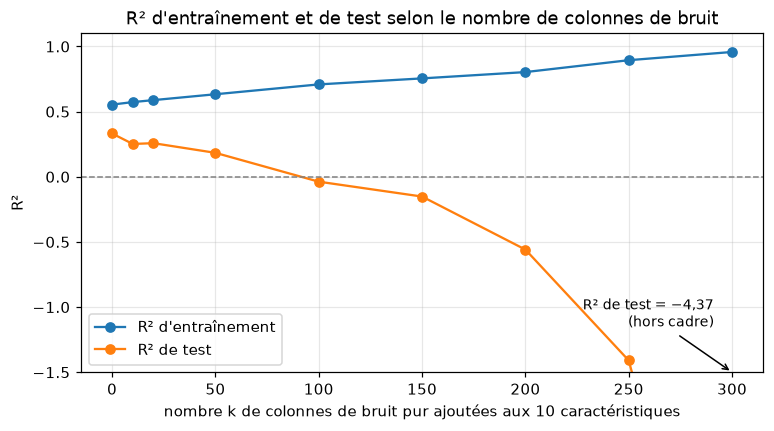

In [5]:
ks = [0, 10, 20, 50, 100, 150, 200, 250, 300]
r2_train, r2_test = [], []
for k in ks:
    Xk_train = np.hstack([X_train, noise_train[:, :k]])
    Xk_test = np.hstack([X_test, noise_test[:, :k]])
    model_k = LinearRegression().fit(Xk_train, y_train)
    r2_train.append(r2(y_train, model_k.predict(Xk_train)))
    r2_test.append(r2(y_test, model_k.predict(Xk_test)))

assert np.isclose(r2_train[0], r2_score(y_train, model.predict(X_train)))   # k = 0 is the model of 1.0
assert np.isclose(r2_test[0], r2_score(y_test, model.predict(X_test)))

print(pd.DataFrame({"R² entraînement": r2_train, "R² test": r2_test}, index=ks).T.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, r2_train, "o-", label="R² d'entraînement")
ax.plot(ks, r2_test, "o-", label="R² de test")
ax.axhline(0, color="gray", ls="--", lw=1)
ax.annotate("R² de test = " + f"{r2_test[-1]:.2f}".replace(".", ",").replace("-", "−") + "\n(hors cadre)",
            xy=(ks[-1], -1.5), xytext=(-12, 30), textcoords="offset points", ha="right", fontsize=9,
            arrowprops=dict(arrowstyle="->"))
ax.set_ylim(-1.5, 1.1)
ax.set_xlabel("nombre k de colonnes de bruit pur ajoutées aux 10 caractéristiques")
ax.set_ylabel("R²")
ax.set_title("R² d'entraînement et de test selon le nombre de colonnes de bruit")
ax.legend(loc="lower left")
plt.show()

**Q6.** Le R² de test de l'arbre est négatif : qu'est-ce que cela veut dire concrètement, RMSE à l'appui ? À partir de combien de colonnes de bruit la régression fait-elle pire que la moyenne sur le test ? Sur les deux courbes, à quoi voit-on le **surapprentissage** — un modèle qui épouse le bruit de son entraînement au point de se dégrader ailleurs ?

**Réponse attendue :** L'arbre obtient 1,000 à l'entraînement (il a mémorisé ses 353 patients, c'est gratuit) et −0,344 au test : **pire que prédire la moyenne**, son RMSE de test (83,0) dépassant celui de la ligne de base (71,7).

Pour le bruit, le R² de test passe sous 0 entre 50 et 100 colonnes (0,184 puis −0,038) et tombe à −4,37 à 300, pendant que celui d'entraînement monte de 0,554 à 0,958 avec du pur hasard. Le surapprentissage se lit dans l'**écart qui se creuse** : les deux courbes partent voisines (0,554 contre 0,332) puis divergent, l'une montant, l'autre s'effondrant. Ce sont ici des **caractéristiques non pertinentes** qui le provoquent.

**Note enseignant.** La baisse du R² de test est une **tendance**, pas une loi : sur ce découpage il remonte entre 10 et 20 colonnes (0,252 → 0,258), un balayage fin place le passage sous 0 à k = 81, et 44 ajouts d'une colonne sur 100 font monter le R² de test. Seule la hausse du R² d'entraînement est un théorème.

## 1.4 Même R², trois diagnostics

Trois jeux mystères, une caractéristique $x$ chacun, 200 points d'entraînement et 100 de test. Les trois R² de test sont égaux à 0,01 près. On lit le diagnostic sur la forme du nuage des résidus : **nuage aléatoire** sans structure, **cône** (les résidus s'écartent quand $\hat y$ grandit : c'est l'**hétéroscédasticité**), ou **U** (résidus positifs aux deux bouts, négatifs au milieu).

**Q7.** Avant de voir les figures : laquelle des trois formes est la seule à dire « ce modèle est sain partout », et que trahit chacune des deux autres ?

**Réponse attendue :** Seul le nuage aléatoire centré sur 0 dit que le modèle est sain partout : il ne reste dans l'erreur aucune structure que le modèle aurait pu exploiter. Le cône dit que la *fiabilité* dépend de la prédiction — petit $\hat y$, petite erreur ; grand $\hat y$, erreur qui peut être énorme : le modèle est juste en moyenne mais pas également fiable, et une barre d'erreur unique serait mensongère aux deux bouts. Le U dit que la relation n'est pas linéaire : le modèle se trompe **systématiquement** dans le même sens selon l'endroit, ce qu'aucun tirage au hasard ne ferait.

Le piège : croire qu'un R² identique décrit une qualité identique, ou qu'un résidu moyen nul suffit — les trois jeux ont le même R² et des résidus centrés, et un seul des trois modèles est utilisable tel quel.

In [6]:
#@title Jeux mystères — exécutez sans lire le code, il donne la réponse
datasets = {}
rng = np.random.default_rng(1); x = rng.uniform(0, 10, 300); datasets["jeu 1"] = (x, 3 * x + 5 + rng.normal(0, 1, 300) * 0.66 * x)
rng = np.random.default_rng(2); x = rng.uniform(0, 10, 300); datasets["jeu 2"] = (x, 0.5 * (x - 2) ** 2 + 5 + rng.normal(0, 2.2, 300))
rng = np.random.default_rng(3); x = rng.uniform(0, 10, 300); datasets["jeu 3"] = (x, 3 * x + 5 + rng.normal(0, 3.74, 300))

results = {}      # dataset name -> (test targets, test predictions)
for name, (x, y_set) in datasets.items():
    x_tr, x_te, y_tr, y_te = train_test_split(x.reshape(-1, 1), y_set, test_size=1 / 3, random_state=0)
    results[name] = (y_te, LinearRegression().fit(x_tr, y_tr).predict(x_te))

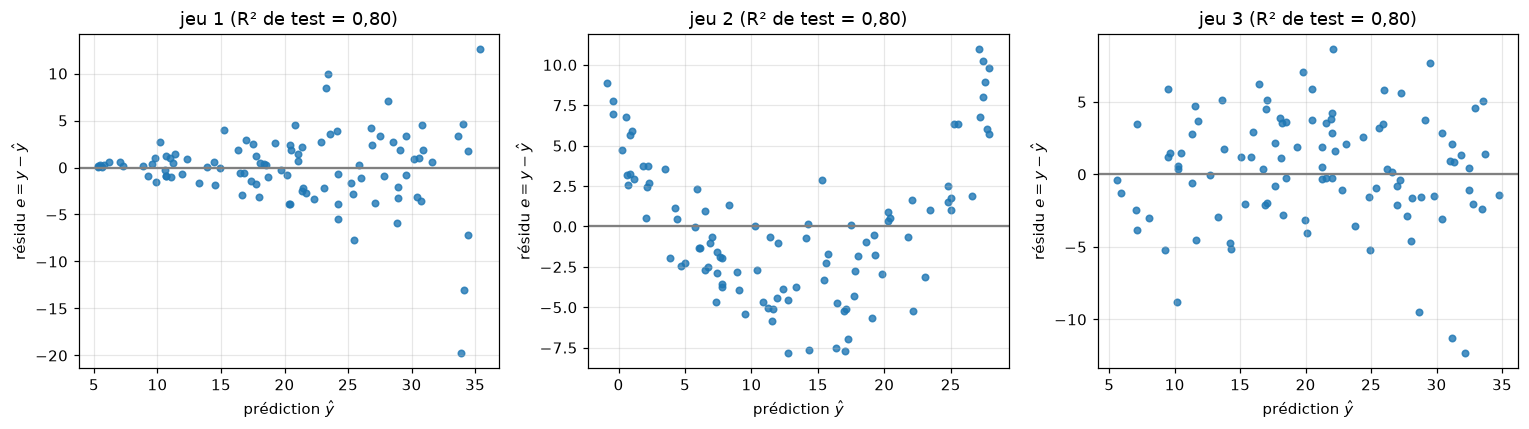

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (y_set, y_set_hat)) in zip(axes, results.items()):
    residuals = y_set - y_set_hat
    ax.scatter(y_set_hat, residuals, s=18, alpha=0.8)
    ax.axhline(0, color="gray", lw=1.5)
    ax.set_title(f"{name} (R² de test = " + f"{r2_score(y_set, y_set_hat):.2f}".replace(".", ",") + ")")
    ax.set_xlabel(r"prédiction $\hat{y}$")
    ax.set_ylabel(r"résidu $e = y - \hat{y}$")
plt.tight_layout()
plt.show()

**Q8.** Associez chaque jeu à son diagnostic. Pour le jeu en cône, où les prédictions sont-elles fiables ? Pour le jeu en U, que proposeriez-vous ?

**Réponse attendue :** Le **jeu 1** est un **cône** : l'écart-type des résidus passe de 1,3 à 3,4 puis 5,7 d'un tiers de $\hat y$ à l'autre, les prédictions ne sont fiables que pour les petits $\hat y$. Le **jeu 2** est un **U** : résidus moyens +1,6 / −3,5 / +1,7 par tiers, le modèle linéaire manque une relation non linéaire, il faut ajouter $x^2$ ou prendre un modèle plus souple. Le **jeu 3** est un **nuage aléatoire** centré sur 0, le seul sain partout. Le même R² de 0,80 cachait trois situations différentes.